# Plot Demo
This notebook demonstrates the analysis capabilities from carps.
For the subset data, it shows which functions generate the plots.
Alternatively, to create the plots, you can also run
```bash
python -m carps.analysis.generate_report \
    --result_path=../results/subsets/logs_normalized.parquet \
    --report_name=report \
    --normalize_results=False
```
from the commandline.

The next cell loads the results and preprocesses them. The resulting dataframe has the following columns:
```yaml
# Identifying information of the run
optimizer_id: The identifier of the optimizer.
task_id: The identifier of the task.
seed: Which seed has been used. The combination of a unique `optimizer_id`, `task_id`, `seed`, equals one optimization run.
experiment_id: Experiment id. Enumeration of all runs.

# Information about the progress of the optimization
n_trials: The number of trials that have been evaluated so far.
n_function_calls: The number of times the objective function has been called. This can differ from `n_trials`, when we are in the multi-fidelity settings and can call the objective function with a lower fidelity. This still results in a full increase of `n_function_calls`, but only a fractional increase in `n_trials`.
n_trials_norm: The number of trials, normalized per run.
time: The elapsed time.
time_norm: The elapsed time, normalized per run. 

# Information about the trial (ask)
trial_info__config: The configuration that has been evaluated.
trial_info__instance: The instance that the configuration has been evaluated on (None for anything but Algorithm Configuration).
trial_info__seed: The seed with which the objective function has been evaluated. In case of stochastic objective functions, we might wish to evaluate the objective function several times with different seeds for the same configuration.
trial_info__budget: The multi-fidelity resource, e.g. the number of epochs. None for anything but multi-fidelity.
trial_info__normalized_budget: The normalized budget (normalized by the maximum budget as indicated by the task).
trial_info__name: An optional name for the trial.
trial_info__checkpoint: An optional checkpoint for the trial.

# Information about the evaluated trial (tell)
## Cost related
trial_value__cost: The objective function value (lower is better).
trial_value__cost_raw: Same as `trial_value__cost`.
trial_value__cost_norm: Normalized cost, min and max are taken over all runs for one task.

## The incumbent cost
trial_value__cost_inc: The incumbent cost (best/lowest cost seen so far).
trial_value__cost_inc_norm: Incumbent cost, normalized over all runs for one task.
trial_value__cost_inc_norm_log: Logarithm of incumbent cost.

### Multi-objective
hypervolume: The hypervolume as calculated over all runs for one task.
reference_point: Reference point as determined over all runs for one task (worst seen combo).

## Time related
trial_value__time: The time the objective function took to evaluate.
trial_value__virtual_time: If the objective function is a surrogate, it can still return an evaluation time. This is marked then as virtual time.
trial_value__status: The status of the trial. Mostly hopefully `SUCCESS`.
trial_value__starttime: The start time of the objective function evaluation.
trial_value__endtime: The end time of the objective function evaluation.

# Information about the task
benchmark_id: The identifier of the benchmark collection the task belongs to.
task_type: The task type, either blackbox, multi-fidelity, multi-objective, or multi-fidelity-objective / momf.
subset_id: The subset id, mostly `None`, `dev` or `test`.
set: Another name for `subset_id`.
task.optimization_resources.n_trials: The optimization resources for the tasks in terms of number of trials.
```

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from carps.analysis.generate_report import load_results
from carps.analysis.utils import filter_only_final_performance, get_color_palette, savefig, setup_seaborn

%matplotlib inline

setup_seaborn(font_scale=1.1)

# Load results from file, they are already normalized in this case
results_full = load_results(result_path="../results/subsets/logs_normalized.parquet", normalize=False)

key_performance = "trial_value__cost_inc_norm"
key_agg = "median"
figure_dir = "figures"

# We only plot subset blackbox test
results = results_full[(results_full["task_type"]=="blackbox") & (results_full["set"]=="test")]
palette = get_color_palette(df=results)
# We get only the final performance for each curve
df_final = filter_only_final_performance(df=results, x_column="n_trials_norm", max_x=1)

[12:18:22] INFO     Loading results from ../results/subsets/logs_normalized.parquet         ]8;id=926362;file:///home/numina/Documents/repos/CARP-S-Experiments/lib/CARP-S/carps/analysis/generate_report.py\generate_report.py]8;;\:]8;id=415556;file:///home/numina/Documents/repos/CARP-S-Experiments/lib/CARP-S/carps/analysis/generate_report.py#1000\1000]8;;\

[12:18:36] INFO     Preprocessing results                                                   ]8;id=679965;file:///home/numina/Documents/repos/CARP-S-Experiments/lib/CARP-S/carps/analysis/generate_report.py\generate_report.py]8;;\:]8;id=255551;file:///home/numina/Documents/repos/CARP-S-Experiments/lib/CARP-S/carps/analysis/generate_report.py#1004\1004]8;;\

           INFO     Columns: Index(['task_id', 'optimizer_id', 'seed', 'level_3',           ]8;id=127840;file:///home/numina/Documents/repos/CARP-S-Experiments/lib/CARP-S/carps/analysis/generate_report.py\generate_report.py]8;;\:]8;id=393254;file:///home/numina/Documents/repos/CARP-S-Experiments/lib/CARP-S/carps/analysis/generate_report.py#1005\1005]8;;\
                    'n_trials',                                                                                    
                           'n_function_calls', 'trial_info__config',                                               
                    'trial_info__instance',                                                                        
                           'trial_info__seed', 'trial_info__budget',                                               
                           'trial_info__normalized_budget', 'trial_info__name',                                    
                           'trial_info__checkpoint', 'trial_value__cost',                                          
                    'trial_value__time',                                                                           
                           'trial_value__virtual_time', 'trial_value__status',                                     
                           'trial_value__starttime', 'trial_value__endtime',                                       
                    'benchmark_id',                                                                                
                           'task_type', 'subset_id',                                                               
                    'task.optimization_resources.n_trials',                                                        
                           'trial_value__cost_raw', 'trial_value__cost_inc', 'time',                               
                           'experiment_id', 'n_trials_norm', 'hypervolume',                                        
                    'reference_point',                                                                             
                           'minimum_cost', 'trial_value__cost_norm',                                               
                    'trial_value__cost_log',                                                                       
                           'trial_value__cost_inc_log', 'trial_value__cost_log_norm',                              
                           'trial_value__cost_inc_log_norm', 'trial_value__cost_inc_norm',                         
                           'trial_value__cost_inc_norm_log', 'time_norm'],                                         
                          dtype='object')                                                                          

           INFO     ...skipping normalization as requested                                  ]8;id=781054;file:///home/numina/Documents/repos/CARP-S-Experiments/lib/CARP-S/carps/analysis/generate_report.py\generate_report.py]8;;\:]8;id=4265;file:///home/numina/Documents/repos/CARP-S-Experiments/lib/CARP-S/carps/analysis/generate_report.py#1016\1016]8;;\

## Critical Difference Plot
We analyze experimental results from different viewpoints. Most importantly, we aggregate the results via
rankings. We use the library autorank (Herbold, 2020) for determining the ranks and critical differences.
The ranking is performed on the raw performance values, averaged across seeds. To be more precise, we
use the frequentist approach (Demšar, 2006): We use the non-parametric Friedman test as an omnibus test
to determine whether there are any significant differences between the median values of the populations.
We use this test because we have more than two populations, which cannot be assumed to be normally
distributed. We use the post hoc Nemenyi test to infer which differences are significant. The significance level
is α = 0.05. In order to be considered different, the difference between the mean ranks of two optimizers must
be greater than the critical difference.

                      meanrank    median       mad    ci_lower       ci_upper  \
Ax                       3.600 -0.942724  0.538761 -226.282468    3822.706297   
SMAC3-BlackBoxFacade     4.400 -0.920203  0.516573  -85.728002   12320.641226   
HEBO                     5.050 -0.941363  0.789411 -197.807839     274.073038   
SMAC3-HPOFacade          5.350 -0.910165   0.51633  -85.045113   48312.540389   
Scikit_Optimize          6.475 -0.918053   0.51638  -85.484491  312171.010165   
Optuna-TPE               6.525 -0.940631   0.53863 -130.713817    60682.15108   
SyneTune-BORE            6.750 -0.940662  0.712122 -198.040531  133240.347764   
SyneTune-CQR             7.100 -0.908038  0.643375  -84.532188  165051.994275   
Nevergrad-CMA-ES         7.650 -0.905909  0.537699 -159.564467    6987.238698   
Nevergrad-BayesOpt       8.000 -0.916565   0.51676  -85.087062   38860.320569   
RandomSearch             9.150 -0.905329  0.516372  -81.951858  171841.272712   
SyneTune-BOTorch         9.9

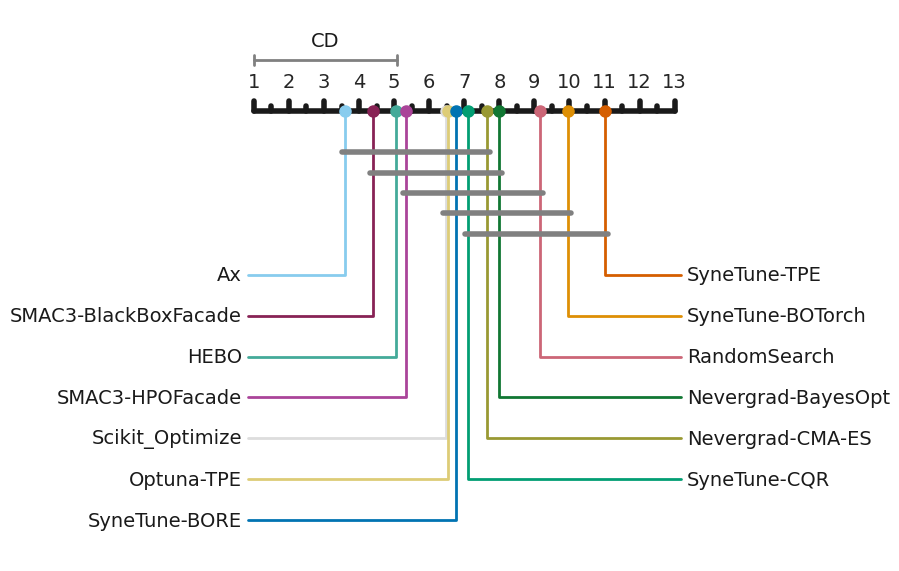

In [2]:
from carps.analysis.generate_report import plot_critical_difference

resulting_files_critical_difference = plot_critical_difference(results, output_dir=figure_dir, show_figure=True)

## Performance per Task
We visualize the final performance per task as a heatmap with tasks as rows and optimizers as columns.
The cells display the raw final performance, averaged over seeds per task, and the colormap indicates 
how well an optimizer performed in comparison. The colormap is using the normalized performance values.

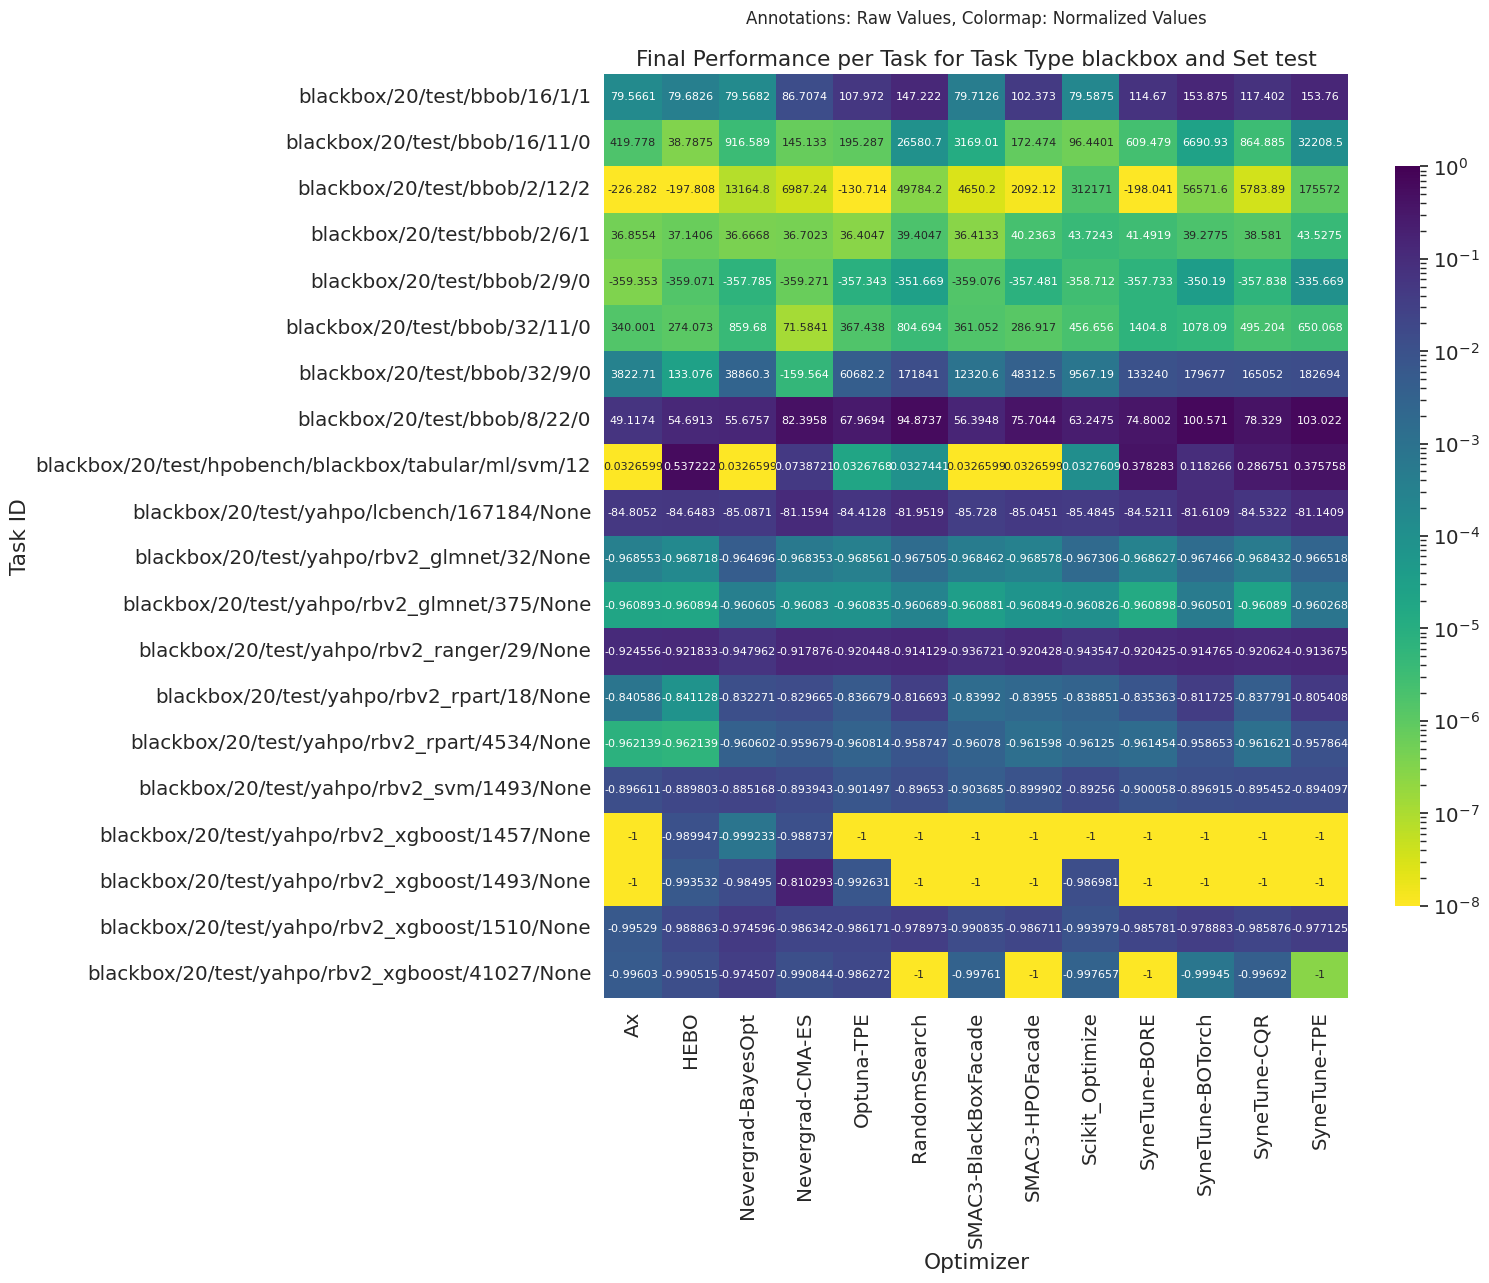

In [3]:
from carps.analysis.generate_report import plot_performance_per_task

resulting_files_performance_per_task = plot_performance_per_task(results, output_dir=figure_dir, replot=True, show_figure=True)

## Final Performance Boxplot
This is a boxplot together with a violin plot, showing the raw (but normalized) distribution of the results.
The optimizers are sorted by their median value to match the critical difference assessment.

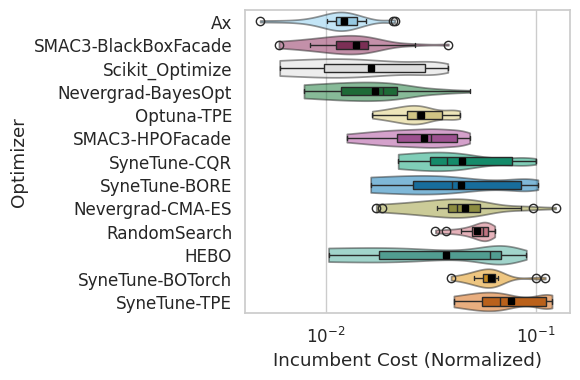

In [4]:
from carps.analysis.generate_report import plot_finalperfboxplot

resulting_files_finalperfboxplot = plot_finalperfboxplot(results, output_dir=figure_dir, replot=True, show_figure=True)

## Performance over Time
We can inspect the anytime performance in two ways. 
The first is visualizing the incumbent cost over iterations: Either aggregated and normalized (and interpolated), or per task.
The caveat of the first method is that we cannot distinguish well between optimizers.
Thus, we normally resort to the ranking over time as determined via statistical testing.

### Aggregated over tasks, normalized
The plot shows the mean incumbent cost over iterations (both normalized and interpolated) with 95%-CI.
Mostly indistinguishable thus not advised.

[12:19:40] INFO     Create dataframe for neat plotting by aligning x-axis / interpolating        ]8;id=729660;file:///home/numina/Documents/repos/CARP-S-Experiments/lib/CARP-S/carps/analysis/gather_data.py\gather_data.py]8;;\:]8;id=842148;file:///home/numina/Documents/repos/CARP-S-Experiments/lib/CARP-S/carps/analysis/gather_data.py#718\718]8;;\
                    budget.                                                                                        

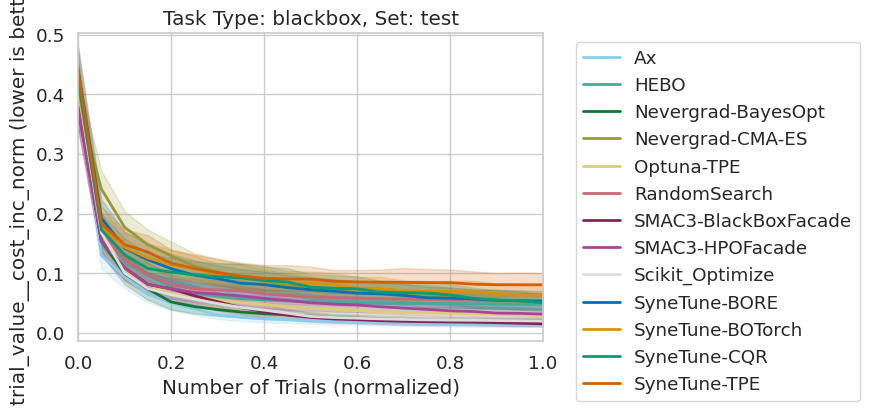

In [5]:
from carps.analysis.generate_report import plot_performance_over_time

%matplotlib inline

resulting_files_perfovertime = plot_performance_over_time(
    results, output_dir=figure_dir, per_task=False, replot=True, show_figure=True
)

### Per Task
⏳ This might take a while because this uses seaborn's grid plot.

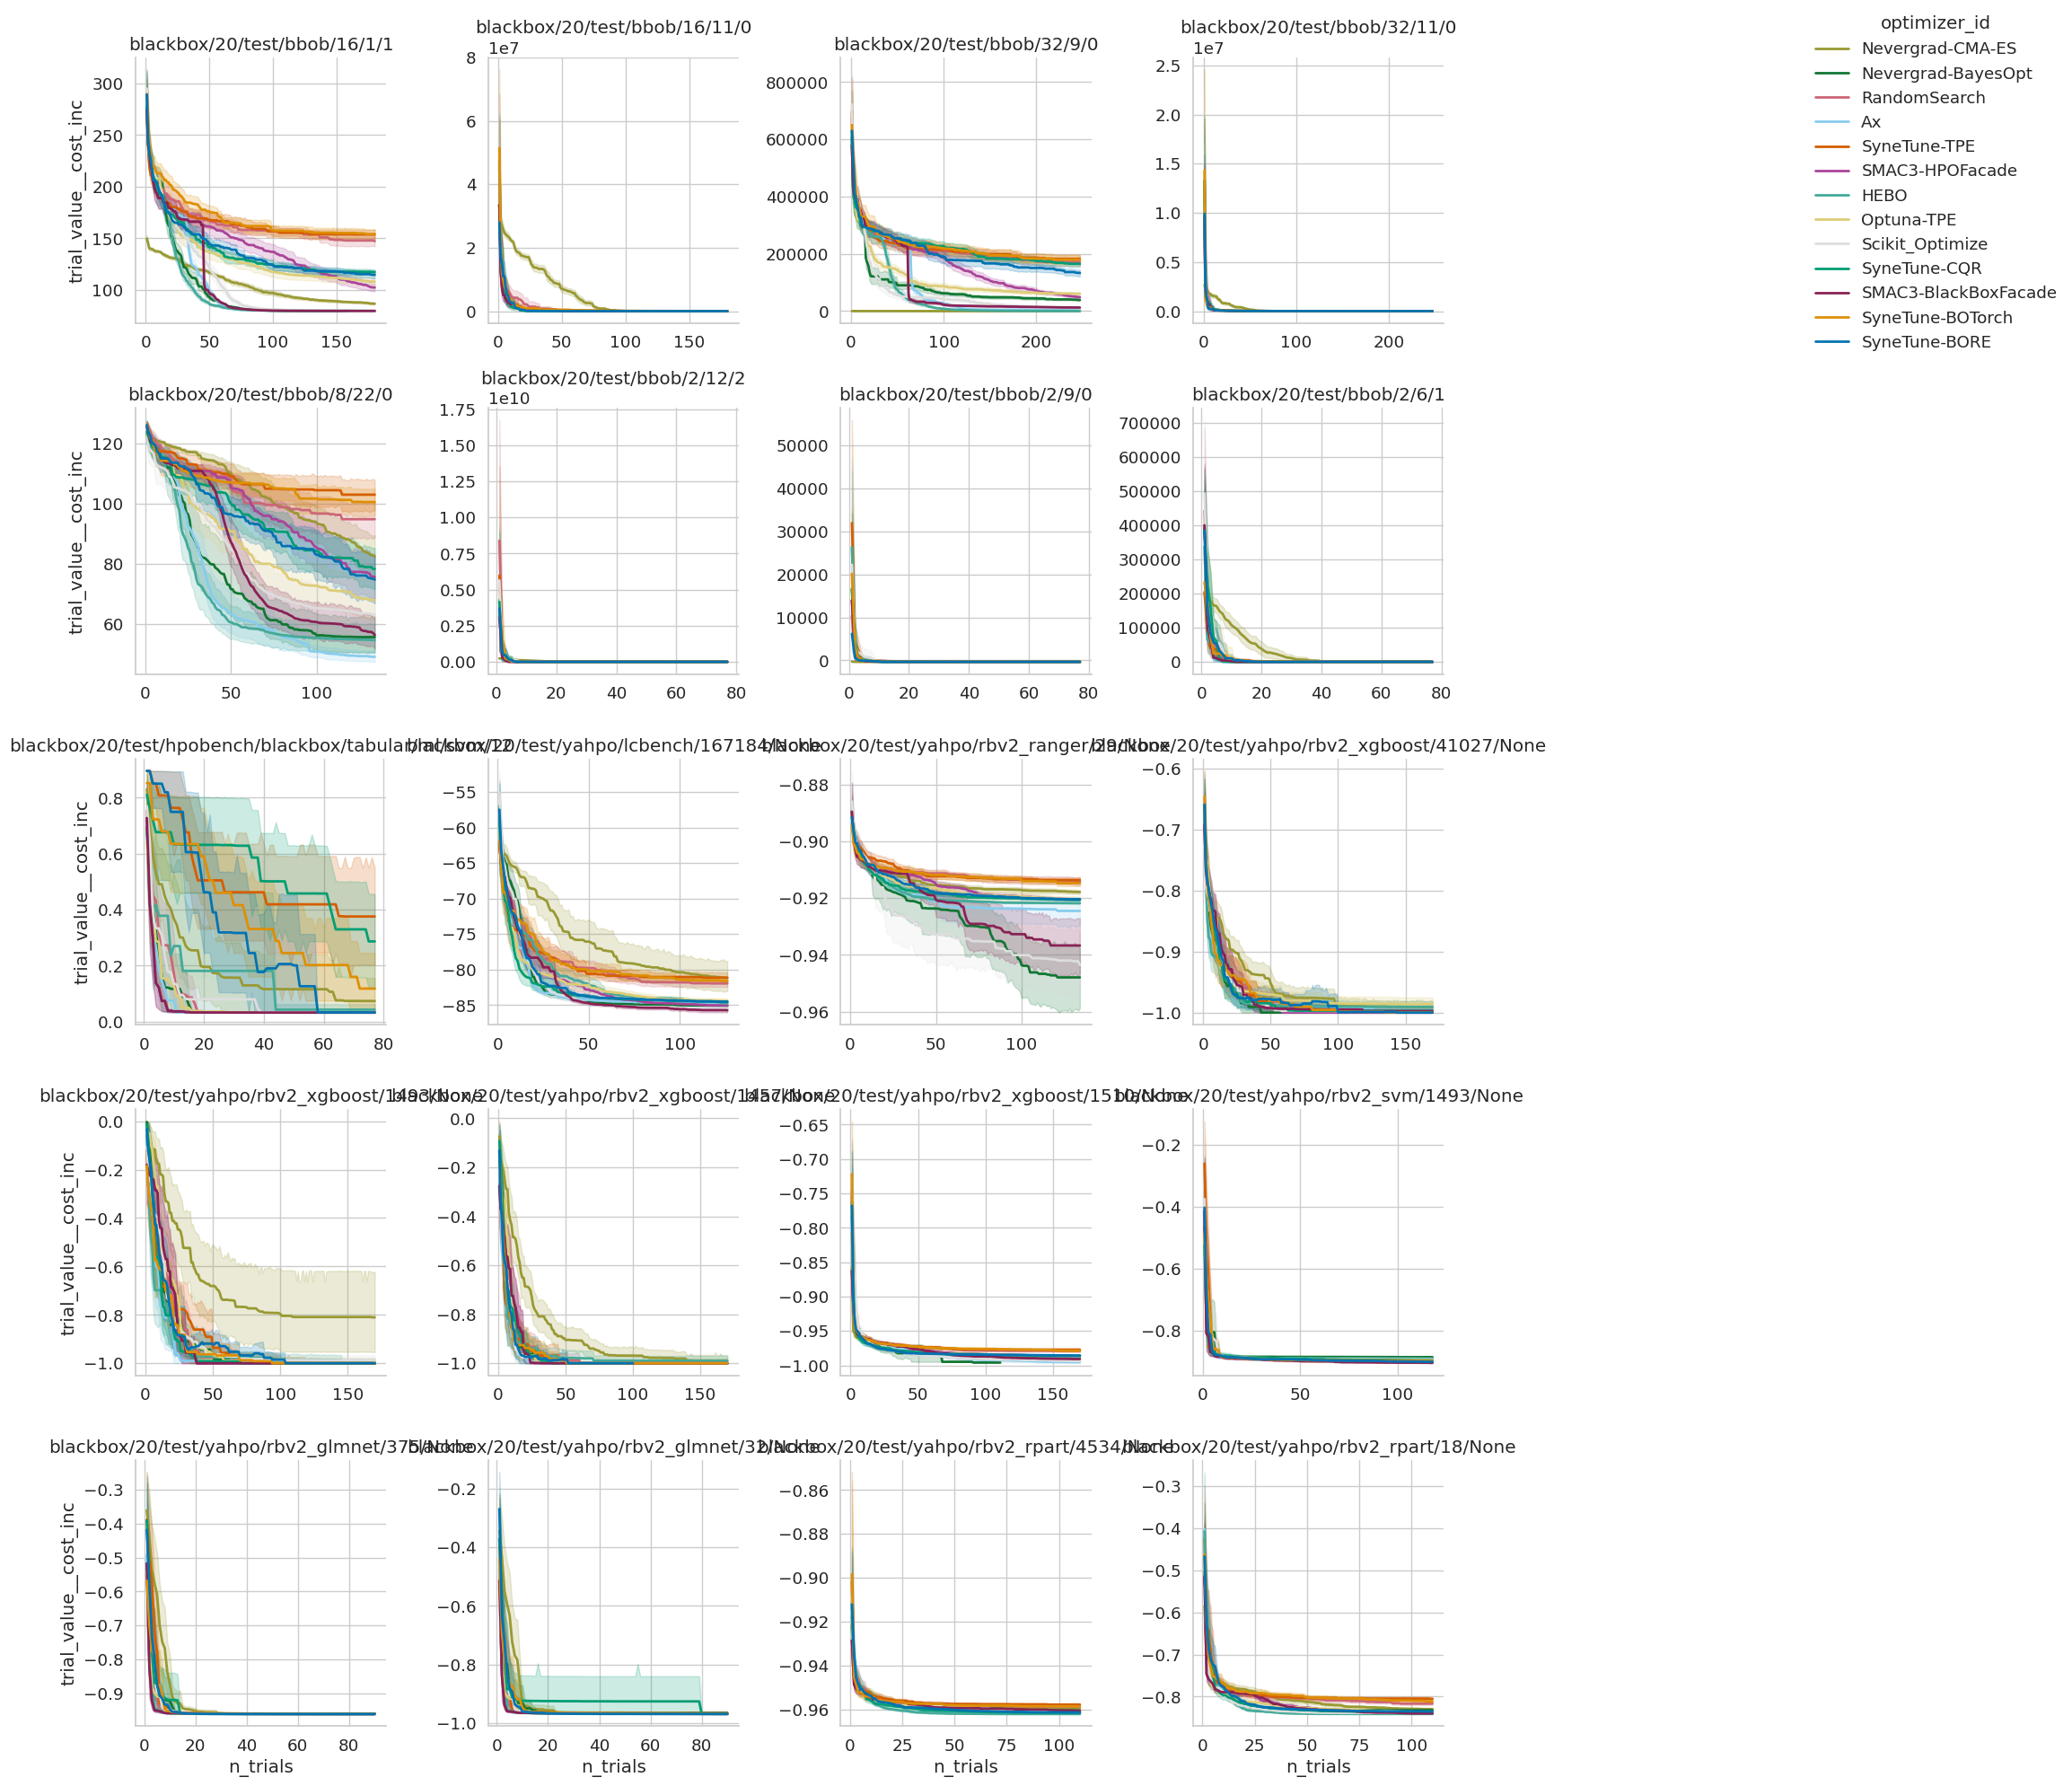

In [8]:
from carps.analysis.generate_report import plot_performance_over_time

%matplotlib inline

resulting_files_perfovertime = plot_performance_over_time(
    results, output_dir=figure_dir, per_task=True, replot=True, show_figure=True
)

### Ranking
The ranking is calculated per step in the same way as for the critical difference diagram, via statistical testing.

⏳ This might take a while...

In [7]:
from carps.analysis.generate_report import plot_ranks_over_time

resulting_files_rank_over_time = plot_ranks_over_time(results, output_dir=figure_dir, replot=True, show_figure=True)

[12:20:59] INFO     Create dataframe for neat plotting by aligning x-axis / interpolating        ]8;id=637933;file:///home/numina/Documents/repos/CARP-S-Experiments/lib/CARP-S/carps/analysis/gather_data.py\gather_data.py]8;;\:]8;id=526821;file:///home/numina/Documents/repos/CARP-S-Experiments/lib/CARP-S/carps/analysis/gather_data.py#718\718]8;;\
                    budget.                                                                                        

[12:21:04] INFO     Budgets: [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55    ]8;id=415619;file:///home/numina/Documents/repos/CARP-S-Experiments/lib/CARP-S/carps/analysis/generate_report.py\generate_report.py]8;;\:]8;id=910034;file:///home/numina/Documents/repos/CARP-S-Experiments/lib/CARP-S/carps/analysis/generate_report.py#116\116]8;;\
                    0.6  0.65                                                                                      
                     0.7  0.75 0.8  0.85 0.9  0.95 1.  ]                                                           

Output()

SyneTune-TPE                 -0.005984      negligible

meanrank    median       mad   ci_lower  \
Nevergrad-CMA-ES         4.450 -0.208660  0.881547 -57.971528   
SMAC3-HPOFacade          4.475 -0.228597  0.828002  -0.928614   
SMAC3-BlackBoxFacade     4.625 -0.228597  0.828002  -0.928614   
Optuna-TPE               5.950 -0.113991  0.791359  -0.920841   
Nevergrad-BayesOpt       6.400 -0.094337  0.811513  -0.921746   
SyneTune-CQR             7.600 -0.052821  0.863599  -0.917366   
RandomSearch             7.650 -0.185417  0.838029  -0.921075   
HEBO                     7.750 -0.093863  0.806684  -0.911304   
Ax                       8.200 -0.108948  0.790073  -0.911999   
SyneTune-BORE            8.300 -0.081418  0.904051  -0.912244   
SyneTune-BOTorch         8.350 -0.177634  0.875627  -0.898492   
Scikit_Optimize          8.550 -0.135598  0.838849  -0.908557   
SyneTune-TPE             8.700 -0.127885  0.898915  -0.902005   

                               ci_upper effect_size   magnitude  \
Nevergrad-CMA-ES       242782400.561856         0.0  negligible   
SMAC3-HPOFacade       3133954989.807209    0.015725  negligible   
SMAC3-BlackBoxFacade  3133954989.807209    0.015725  negligible   
Optuna-TPE            4150906071.088757   -0.076227  negligible   
Nevergrad-BayesOpt    4150906071.088757   -0.091011  negligible   
SyneTune-CQR          4150906071.088757   -0.120456  negligible   
RandomSearch          8391234086.034933   -0.018228  negligible   
HEBO                  4306021416.128559   -0.091638  negligible   
Ax                    4306021700.605274   -0.080347  negligible   
SyneTune-BORE         3702839789.389157   -0.096121  negligible   
SyneTune-BOTorch      3489862340.049786   -0.023818  negligible   
Scikit_Optimize        5638578717.26975   -0.057271  negligible   
SyneTune-TPE          5986251868.631037   -0.061197  negligible   

                     effect_size_above magnitude_above  
Nevergrad-CMA-ES                   0.0      negligible  
SMAC3-HPOFacade               0.015725      negligible  
SMAC3-BlackBoxFacade               0.0      negligible  
Optuna-TPE                   -0.095446      negligible  
Nevergrad-BayesOpt           -0.016539      negligible  
SyneTune-CQR                 -0.033418      negligible  
RandomSearch                  0.105105      negligible  
HEBO                         -0.075078      negligible  
Ax                            0.012743      negligible  
SyneTune-BORE                -0.021872      negligible  
SyneTune-BOTorch              0.072922      negligible  
Scikit_Optimize              -0.033068      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTune-TPE                 -0.005984      negligible  
SyneTu

RecursionError: maximum recursion depth exceeded